## Python Workflow

In [35]:
# Load & Inspect Data
import pandas as pd

# Load the Excel file
df = pd.read_excel("./Campaign_Data_Week1.xlsx")

# Quick look at the data
df.head()


,Interaction ID,Campaign Type,Channel,Customer Type,"Converted (1=yes, 0=no)",Time on Site (seconds),Sales ($)
0,INT0001,B,Instagram,Existing,1,88.14,70.99
1,INT0002,B,Email,Existing,0,42.70,0.00
2,INT0003,B,Email,Existing,1,116.66,59.62
3,INT0004,B,Email,Existing,1,121.61,77.36
4,INT0005,A,Instagram,New,0,59.30,0.00


In [36]:
df.shape

(500, 7)

In [37]:
# Focus on New Customers only
# Filter for new customers
new_customers = df[df["Customer Type"] == "New"]

In [62]:
# Check conversion rate by Campaign + Channel
conversion_summary = new_customers.groupby(["Campaign Type", "Channel"])["Converted (1=yes, 0=no)"].mean().reset_index()
conversion_summary.sort_values(by="Converted (1=yes, 0=no)", ascending=False)

,Campaign Type,Channel,"Converted (1=yes, 0=no)"
3,B,Email,0.645161
0,A,Email,0.617021
4,B,Instagram,0.350000
1,A,Instagram,0.333333
2,A,Web Banner,0.325581
5,B,Web Banner,0.291667


In [63]:
# for conversion rate in % => .mul(100).round(2).mean().reset_index()

Conversion Rate (Convincing New Customers) 

- Highest: Campaign B + Email (64.5%)

- Next best: Campaign A + Email (61.7%)

- Other channels (Instagram, Web Banner) had much lower conversion rates (29-35%)

Promotional tone (Campaign B) via Email is most persuasive for first-time buyers

In [39]:
# Sales Performance by Campaign + Channel (New Customers)
# Sum of sales for new customers
sales_summary = new_customers.groupby(["Campaign Type", "Channel"])["Sales ($)"].sum().reset_index()

sales_summary.sort_values(by="Sales ($)", ascending=False)

,Campaign Type,Channel,Sales ($)
0,A,Email,2124.47
3,B,Email,1382.38
1,A,Instagram,969.46
2,A,Web Banner,633.06
4,B,Instagram,416.14
5,B,Web Banner,318.92


Total Sales (Revenue from New Customers)

- Highest: Campaign A + Email ($2124.47)

- Second: Campaign B + Email ($1382.38)

- Instagram and Web Banner lag behind significantly

Conversational tone (Campaign A) via Email generates the most revenue from new customers

In [40]:
# Combine Conversion Rate + Sales
# Merge conversion and sales summaries
performance = pd.merge(conversion_summary, sales_summary, on = ["Campaign Type", "Channel"])
performance.rename(columns = {"Converted (1=yes, 0=no)": "Conversion Rate", "Sales ($)": "Total Sales"}, inplace=True)

performance

,Campaign Type,Channel,Conversion Rate,Total Sales
0,A,Email,0.617021,2124.47
1,A,Instagram,0.333333,969.46
2,A,Web Banner,0.325581,633.06
3,B,Email,0.645161,1382.38
4,B,Instagram,0.350000,416.14
5,B,Web Banner,0.291667,318.92


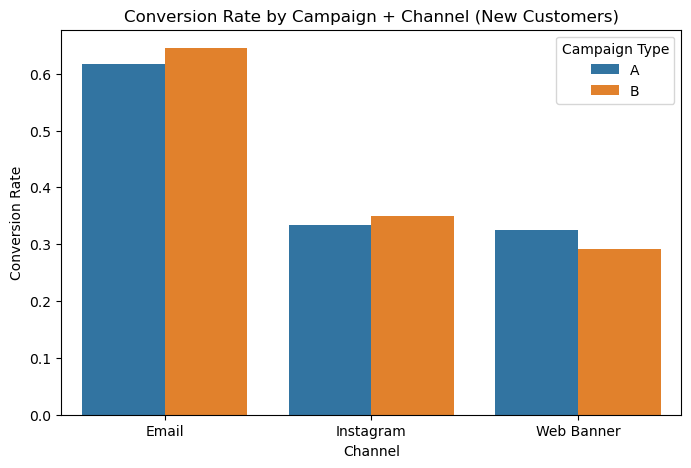

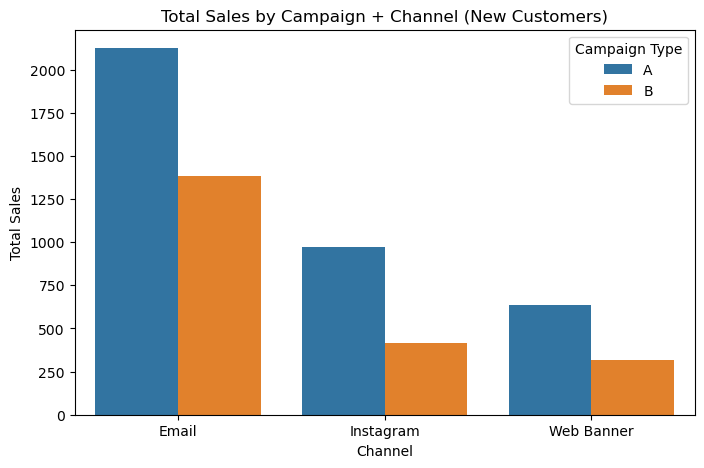

In [41]:
# Visualize Results
import seaborn as sns
import matplotlib.pyplot as plt

# Conversion Rate Plot
plt.figure(figsize = (8,5))
sns.barplot(data = performance, x = "Channel", y = "Conversion Rate", hue = "Campaign Type")
plt.title("Conversion Rate by Campaign + Channel (New Customers)")
plt.show()

# Sales Plot
plt.figure(figsize = (8,5))
sns.barplot(data = performance, x = "Channel", y = "Total Sales", hue = "Campaign Type")
plt.title("Total Sales by Campaign + Channel (New Customers)")
plt.show()

In [42]:
# Campaign A (conversational), Campaign B (promotional)

Conversion Rate (which combo convinces new customers most often)
- Campaign B + Email

Total Sales (which combo generates the most revenue from new customers)
- Campaign A + Email

Together, these metrics highlight the best-performing campaign + channel combo to double down on

In [43]:
# Efficiency Metric - helps to see not just who converts and spends, but how quickly those sales happen relative to time spent on site

In [44]:
# Efficiency Metric: Sales per Second on Site (for new customers)
new_customers["Sales_per_Second"] = new_customers["Sales ($)"] / new_customers["Time on Site (seconds)"]

# Group by campaign + channel
efficiency_summary = new_customers.groupby(["Campaign Type", "Channel"])["Sales_per_Second"].mean().reset_index()

efficiency_summary.sort_values(by="Sales_per_Second", ascending=False)


C:\Users\ALKAPODDAR\AppData\Local\Temp\ipykernel_29468\3192896317.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_customers["Sales_per_Second"] = new_customers["Sales ($)"] / new_customers["Time on Site (seconds)"]


,Campaign Type,Channel,Sales_per_Second
3,B,Email,0.380572
0,A,Email,0.363539
4,B,Instagram,0.254106
1,A,Instagram,0.244392
2,A,Web Banner,0.180557
5,B,Web Banner,0.129964


Efficiency (Sales per Second on Site)

- Highest: Email (both Campaign A & B)

- Campaign B + Email: 0.38

- Campaign A + Email: 0.36

- Instagram and Web Banner are less efficient (0.13 - 0.25)

Email campaigns convert fastest relative to time spent on site

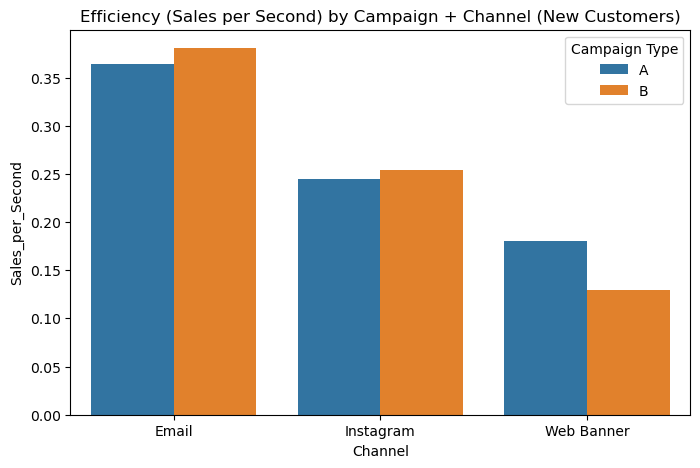

In [46]:
# Visualize Efficiency
# Efficiency Plot
plt.figure(figsize=(8,5))
sns.barplot(data=performance_full, x="Channel", y="Sales_per_Second", hue="Campaign Type")
plt.title("Efficiency (Sales per Second) by Campaign + Channel (New Customers)")
plt.show()

In [45]:
# Merge with Previous Performance Data
# Merge efficiency with conversion + sales
performance_full = pd.merge(performance, efficiency_summary, on=["Campaign Type", "Channel"])

performance_full.sort_values(by="Total Sales", ascending=False)

,Campaign Type,Channel,Conversion Rate,Total Sales,Sales_per_Second
0,A,Email,0.617021,2124.47,0.363539
3,B,Email,0.645161,1382.38,0.380572
1,A,Instagram,0.333333,969.46,0.244392
2,A,Web Banner,0.325581,633.06,0.180557
4,B,Instagram,0.350000,416.14,0.254106
5,B,Web Banner,0.291667,318.92,0.129964


Tip:
- For volume -> Total Sales

- For quick wins -> Efficiency

- For long-term loyalty -> Conversion Rate

In [47]:
# rank the combos automatically (e.g., best overall by weighted score across all three metrics)
# Normalize Metrics (so they’re comparable)
from sklearn.preprocessing import MinMaxScaler

# Copy performance_full
ranking_df = performance_full.copy()

# Select metrics to normalize
metrics = ["Conversion Rate", "Total Sales", "Sales_per_Second"]

scaler = MinMaxScaler()
ranking_df[[m + "_Norm" for m in metrics]] = scaler.fit_transform(ranking_df[metrics])

ranking_df

,Campaign Type,Channel,Conversion Rate,Total Sales,Sales_per_Second,Conversion Rate_Norm,Total Sales_Norm,Sales_per_Second_Norm
0,A,Email,0.617021,2124.47,0.363539,0.920395,1.000000,0.932030
1,A,Instagram,0.333333,969.46,0.244392,0.117871,0.360300,0.456600
2,A,Web Banner,0.325581,633.06,0.180557,0.095941,0.173986,0.201881
3,B,Email,0.645161,1382.38,0.380572,1.000000,0.588995,1.000000
4,B,Instagram,0.350000,416.14,0.254106,0.165019,0.053845,0.495364
5,B,Web Banner,0.291667,318.92,0.129964,0.000000,0.000000,0.000000


In [48]:
# Weighted Score Calculation
# Define weights 
weights = {
    "Conversion Rate_Norm": 0.4,   # prioritize convincing new customers
    "Total Sales_Norm": 0.4,       # revenue impact
    "Sales_per_Second_Norm": 0.2   # efficiency
}

# Calculate weighted score
ranking_df["Weighted_Score"] = (
    ranking_df["Conversion Rate_Norm"] * weights["Conversion Rate_Norm"] +
    ranking_df["Total Sales_Norm"] * weights["Total Sales_Norm"] +
    ranking_df["Sales_per_Second_Norm"] * weights["Sales_per_Second_Norm"]
)

# Sort by score
ranking_df = ranking_df.sort_values("Weighted_Score", ascending=False)

ranking_df[["Campaign Type", "Channel", "Weighted_Score"]]

,Campaign Type,Channel,Weighted_Score
0,A,Email,0.954564
3,B,Email,0.835598
1,A,Instagram,0.282588
4,B,Instagram,0.186618
2,A,Web Banner,0.148347
5,B,Web Banner,0.000000


In [69]:
# Visualize Ranking
# plt.figure(figsize=(8,5))
# sns.barplot(data=ranking_df, x="Channel", y="Weighted_Score", hue="Campaign Type")
# plt.title("Overall Ranking by Campaign + Channel (New Customers)")
# plt.show()

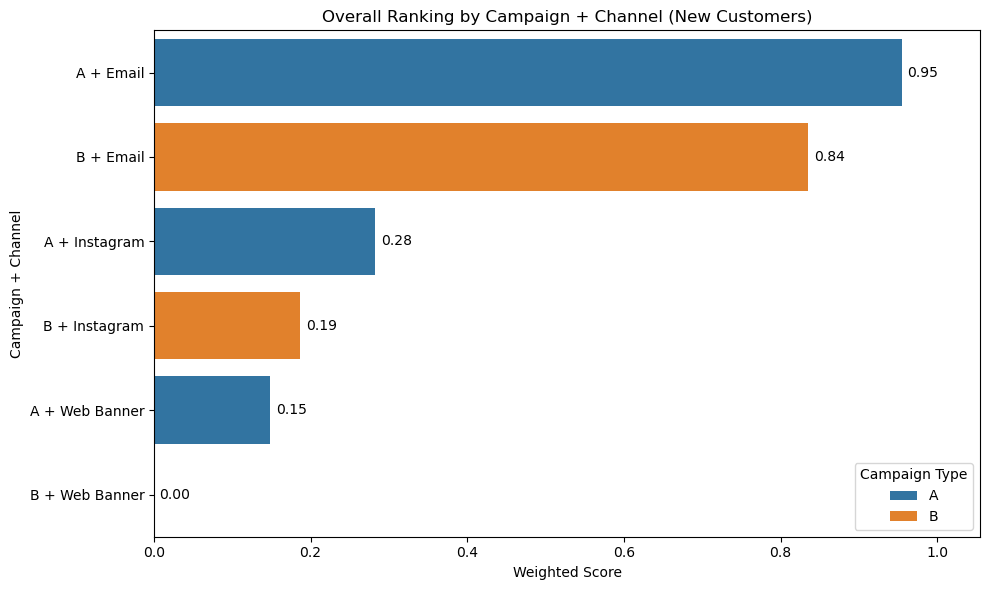

In [67]:
# Labeled Ranking
ranking_df["Combo"] = (
    ranking_df["Campaign Type"] + " + " + ranking_df["Channel"]
)

# Sort highest score → lowest score
plot_df = ranking_df.sort_values(
    "Weighted_Score",
    ascending=False
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=plot_df,
    y="Combo",
    x="Weighted_Score",
    hue="Campaign Type"
)

# Show weighted score beside each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=4
    )

plt.xlabel("Weighted Score")
plt.ylabel("Campaign + Channel")
plt.title("Overall Ranking by Campaign + Channel (New Customers)")

plt.xlim(0, plot_df["Weighted_Score"].max() + 0.1)

plt.legend(title="Campaign Type")
plt.tight_layout()
plt.show()

Weighted Ranking (Balanced Score across Conversion, Sales, Efficiency)
- Top: Campaign A + Email (Score around 0.95)

- Second: Campaign B + Email (Score around 0.83)

- All other combos score far lower (<0.3)

Overall, Campaign A + Email is the best-performing combo to double down on

top-ranked combo (the one to double down on)
- Campaign A + Channel Email -> This is where NewCo should invest more budget

## Final Recommendation for NewCo

Invest more budget in Campaign A + Email 
- It balances persuasion, revenue, and efficiency, making it the strongest driver of new customer growth

Use Campaign B + Email as a secondary strategy for promotions or limited-time offers
- Scale back Instagram and Web Banner for acquisition—they’re not cost-effective for new customers

## Asked Excel Workflow (in Python)

In [50]:
# Pivot: Total Sales by Campaign
pivot_campaign = df.pivot_table(
    values="Sales ($)", 
    index="Campaign Type", 
    aggfunc="sum"
)
pivot_campaign

,Sales ($)
Campaign Type,
A,5869.56
B,8790.04


In [51]:
# Pivot: Total Sales by Channel
pivot_channel = df.pivot_table(
    values="Sales ($)", 
    index="Channel", 
    aggfunc="sum"
)
pivot_channel

,Sales ($)
Channel,
Email,7909.31
Instagram,3873.41
Web Banner,2876.88


In [52]:
# Pivot: Sales by Campaign + Channel
pivot_combo = df.pivot_table(
    values="Sales ($)", 
    index=["Campaign Type", "Channel"], 
    aggfunc="sum"
)
pivot_combo

Sales ($)
Campaign Type Channel              
A             Email         2952.37
              Instagram     2162.90
              Web Banner     754.29
B             Email         4956.94
              Instagram     1710.51
              Web Banner    2122.59

In [53]:
# Filter for new customers (like slicer in Excel)
new_customers = df[df["Customer Type"] == "New"]

# Pivot for new customers only
pivot_new_combo = new_customers.pivot_table(
    values="Sales ($)", 
    index=["Campaign Type", "Channel"], 
    aggfunc="sum"
)
pivot_new_combo

Sales ($)
Campaign Type Channel              
A             Email         2124.47
              Instagram      969.46
              Web Banner     633.06
B             Email         1382.38
              Instagram      416.14
              Web Banner     318.92

C:\Users\ALKAPODDAR\AppData\Local\Temp\ipykernel_29468\2285418090.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_customers["Sales_per_Second"] = new_customers["Sales ($)"] / new_customers["Time on Site (seconds)"]


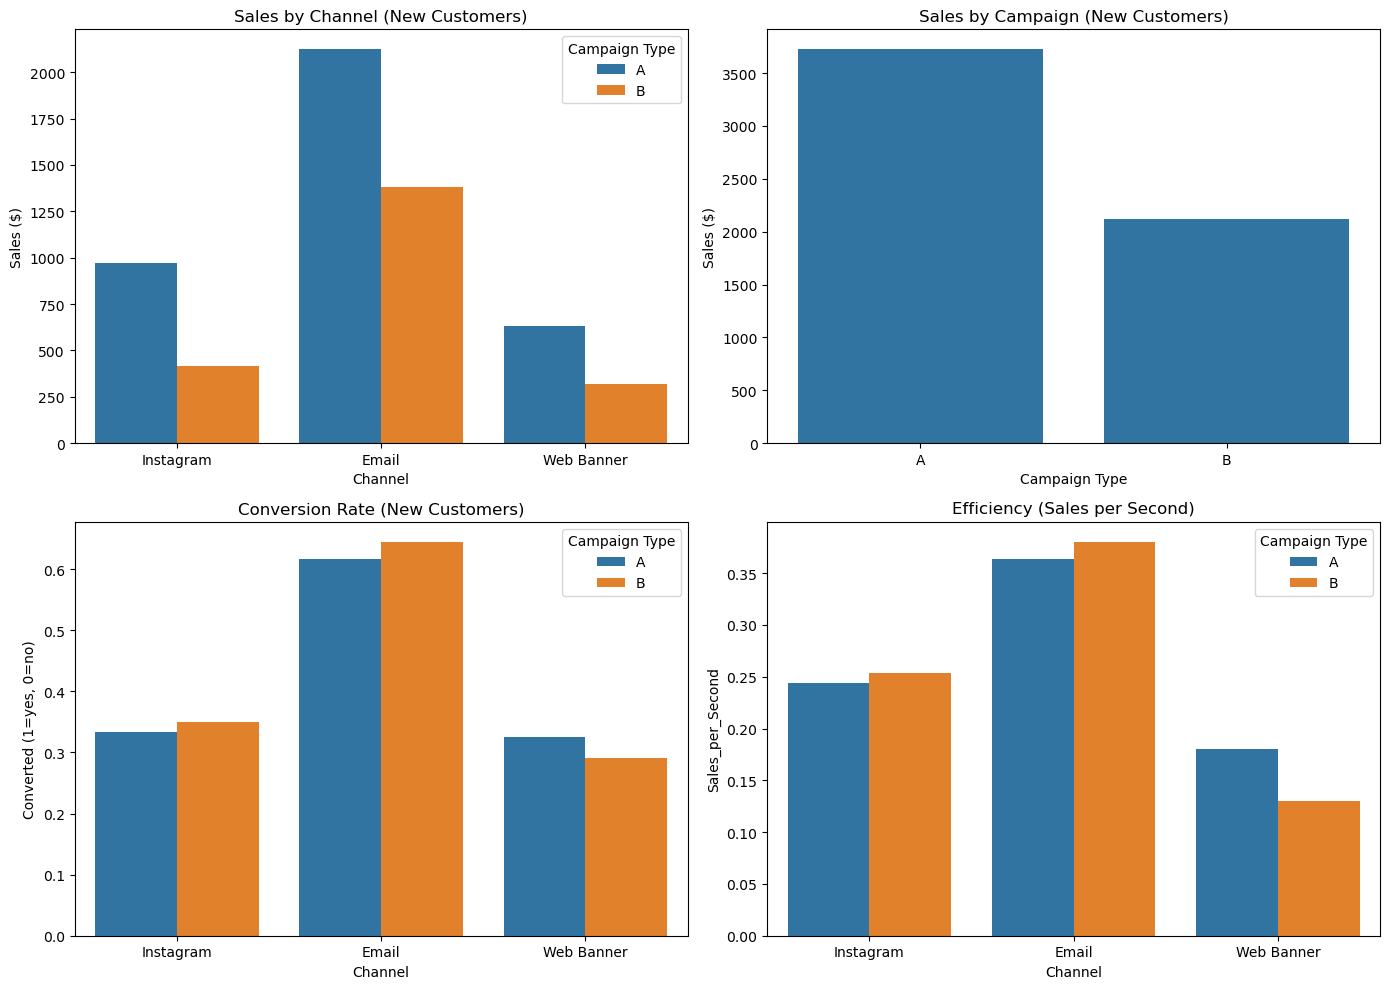

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter new customers
new_customers = df[df["Customer Type"]=="New"]

fig, axes = plt.subplots(2, 2, figsize=(14,10))

# 1. Sales by channel
sns.barplot(data=new_customers, x="Channel", y="Sales ($)", hue="Campaign Type", estimator=sum, errorbar=None, ax=axes[0,0])
axes[0,0].set_title("Sales by Channel (New Customers)")

# 2. Sales by campaign
sns.barplot(data=new_customers, x="Campaign Type", y="Sales ($)", estimator=sum, errorbar=None, ax=axes[0,1])
axes[0,1].set_title("Sales by Campaign (New Customers)")

# 3. Conversion rate
sns.barplot(data=new_customers, x="Channel", y="Converted (1=yes, 0=no)", hue="Campaign Type", estimator="mean", errorbar=None, ax=axes[1,0])
axes[1,0].set_title("Conversion Rate (New Customers)")

# 4. Efficiency (Sales per Second)
new_customers["Sales_per_Second"] = new_customers["Sales ($)"] / new_customers["Time on Site (seconds)"]
sns.barplot(data=new_customers, x="Channel", y="Sales_per_Second", hue="Campaign Type", errorbar=None, ax=axes[1,1])
axes[1,1].set_title("Efficiency (Sales per Second)")

plt.tight_layout()
plt.show()
